## Inspired from https://arxiv.org/pdf/1609.03499

In [1]:
import tensorflow as tf

2026-04-15 16:15:27.216812: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776269727.411136      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776269727.467959      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776269727.938611      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776269727.938646      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776269727.938649      23 computation_placer.cc:177] computation placer alr

In [2]:
class GatedActivationUnit(tf.keras.layers.Layer):
    def __init__(self, activation="tanh", **kwargs):
        super().__init__(**kwargs)
        self.activation = tf.keras.activations.get(activation)

    def call(self, inputs):
        n_filters = inputs.shape[-1] // 2
        linear_output = self.activation(inputs[..., :n_filters])
        gate = tf.keras.activations.sigmoid(inputs[..., n_filters:])
        return self.activation(linear_output) * gate

In [3]:
def wavenet_residual_block(inputs, n_filters, dilation_rate):
    z = tf.keras.layers.Conv1D(2 * n_filters, kernel_size=2, padding="causal",
                            dilation_rate=dilation_rate)(inputs)
    z = GatedActivationUnit()(z)
    z = tf.keras.layers.Conv1D(n_filters, kernel_size=1)(z)
    return tf.keras.layers.Add()([z, inputs]), z

In [4]:
tf.random.set_seed(42)

n_layers_per_block = 10  
n_blocks = 3
n_filters = 128 
n_outputs = 256  

inputs = tf.keras.layers.Input(shape=[None]) 

z = tf.keras.layers.Embedding(256, n_filters)(inputs) 
z = tf.keras.layers.Conv1D(n_filters, kernel_size=2, padding="causal")(z) 


skip_to_last = []

for dilation_rate in [2**i for i in range(n_layers_per_block)] * n_blocks:
    z, skip = wavenet_residual_block(z, n_filters, dilation_rate)
    skip_to_last.append(skip)

z = tf.keras.activations.relu(tf.keras.layers.Add()(skip_to_last))
z = tf.keras.layers.Conv1D(n_filters, kernel_size=1, activation="relu")(z)
Y_preds = tf.keras.layers.Conv1D(n_outputs, kernel_size=1)(z)

full_wavenet_model = tf.keras.Model(inputs=[inputs], outputs=[Y_preds])

I0000 00:00:1776269753.981288      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776269753.986939      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [5]:
import glob

file_paths = sorted(glob.glob("/kaggle/input/datasets/dromosys/ljspeech/LJSpeech-1.1/wavs/*.wav"))
file_paths = [str(p) for p in file_paths]

SEQ_LEN = 1024
BATCH_SIZE = 8
MU = 255

In [6]:
def load_wav(path):
    audio = tf.io.read_file(path)
    wav, _ = tf.audio.decode_wav(audio, desired_channels=1)

    wav = tf.squeeze(wav, axis=-1)
    wav = tf.clip_by_value(wav, -1.0, 1.0)

    return tf.cast(wav, tf.float32)

def encode_wav(wav):
    wav = tf.cast(wav, tf.float32)

    wav = tf.clip_by_value(wav, -1.0, 1.0)

    mu = tf.cast(MU, tf.float32)

    x = tf.sign(wav) * tf.math.log1p(mu * tf.abs(wav)) / tf.math.log1p(mu)

    x = (x + 1.0) * 0.5 * mu

    return tf.cast(x, tf.int32)

def frame_audio(x):
    x = tf.ensure_shape(x, [None])  
    return tf.signal.frame(
        x,
        frame_length=SEQ_LEN + 1,
        frame_step=SEQ_LEN,
        axis=0,
        pad_end=True
    )

In [7]:
def make_dataset(files):
    ds = tf.data.Dataset.from_tensor_slices(tf.convert_to_tensor(files, dtype=tf.string))

    ds = ds.map(load_wav, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(encode_wav, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.map(frame_audio, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.flat_map(lambda x: tf.data.Dataset.from_tensor_slices(x))

    ds = ds.map(lambda x: (x[:-1], x[1:]), num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.shuffle(10000)
    ds = ds.batch(BATCH_SIZE, drop_remainder=False)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

train_size = int(0.9 * len(file_paths))
train_ds = make_dataset(file_paths[:train_size])
valid_ds = make_dataset(file_paths[train_size:])

In [8]:
full_wavenet_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                           metrics=[tf.keras.metrics.SparseCategoricalAccuracy])

history = full_wavenet_model.fit(train_ds, validation_data=valid_ds, epochs=10, steps_per_epoch=1500, validation_steps=50)

Epoch 1/10


I0000 00:00:1776269774.851895      70 service.cc:152] XLA service 0x7f59000576b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776269774.851933      70 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776269774.851936      70 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776269778.434166      70 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-15 16:16:23.112316: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-15 16:16:23.466700: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-15 16:16:23.468986: E external/local_xl

   1/1500 ━━━━━━━━━━━━━━━━━━━━ 15:29:26 37s/step - loss: 5.5496 - sparse_categorical_accuracy: 0.0045

I0000 00:00:1776269794.516686      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 169s 88ms/step - loss: 3.4283 - sparse_categorical_accuracy: 0.1090 - val_loss: 2.8602 - val_sparse_categorical_accuracy: 0.1526
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 132s 88ms/step - loss: 2.7948 - sparse_categorical_accuracy: 0.1607 - val_loss: 2.6468 - val_sparse_categorical_accuracy: 0.1790
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 132s 88ms/step - loss: 2.6918 - sparse_categorical_accuracy: 0.1747 - val_loss: 2.6493 - val_sparse_categorical_accuracy: 0.1881
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 133s 89ms/step - loss: 2.6408 - sparse_categorical_accuracy: 0.1820 - val_loss: 2.5920 - val_sparse_categorical_accuracy: 0.1889
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 132s 88ms/step - loss: 2.5991 - sparse_categorical_accuracy: 0.1899 - val_loss: 2.5916 - val_sparse_categorical_accuracy: 0.1908
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 132s 88ms/step - loss: 2.5554 - sparse_categorical_accuracy: 0.1988 - val_loss: 2.5010 - val_sparse_categorical_ac

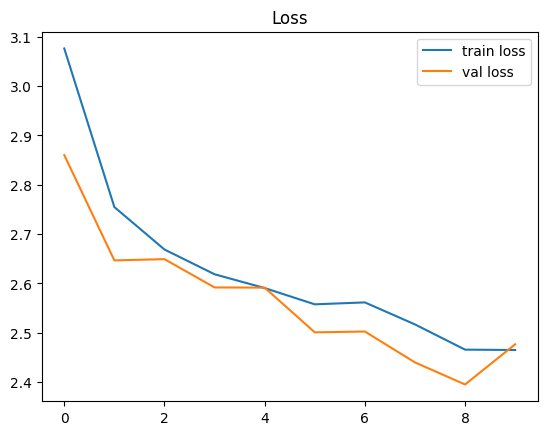

In [9]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.legend()
plt.title("Loss")
plt.show()